"""  
아래 내용이 필수적으로 들어가야 합니다.

- 다중선형회귀의 기본 가정 여섯가지
- 회귀 분석의 평가 방법
    - 시각화
    - 통계지표: 유의성 검정, 성능 평가
- 비선형 회귀 모델
    - 다항, 지수, 로그, 스플라인  

"""

# **회귀 기초 복습**
## 회귀란?
- 연속적인 데이터에서 선형회귀, 비선형회귀, 라쏘회귀, 다항회귀 등을 통해 패턴을 찾아내는 통계적 방법
- MSE, MAE, R-square, Adjusted R-square 등으로 평가
## 단순/다중 선형회귀분석
- 단순 = 독립변수 하나
- 다중 = 독립변수 두 개 이상
## 회귀선은 어떻게 찾을까?
- **최소제곱법**을 활용해 $ {(잔차)}^2 $의 합을 최소화하는 회귀선을 찾는다
    > 잔차 = 예측값 - 관측값
- 최소제곱법은 보통 **OLS**(Ordinary Least Square, 최소자승법)이라고도 한다
## 회귀 분석 프로세스
$$ 사전 검증 -> 모델 생성 및 fit -> 모델 평가 -> 모델 성능 개선 $$
- 사전 검증: 데이터 탐색 및 전처리(결측치, 이상치 처리) + *회귀 분석의 기본 가정 6가지 검토*
- 모델 생성 및 fit: 회귀 모델 생성, 학습, 유의성 검정 by *F-검정, T-검정*
- 모델 성능 평가: R-squared, *회귀 분석 후 검증 가능한 가설 검토*
- 모델 성능 개선: 불필요한 변수 제거, *비선형 모델 활용*

# **선형회귀**
## 다중선형회귀의 수식적 이해
$$ y_i = \beta_0+\beta_1X_{1i}+\beta_2X_{2i}+...+\beta_kX_{ki}+\varepsilon_i $$
- 탐색하고자 하는 종속변수 y를 영향을 줄 것으로 생각되는 여러 독립변수 X에 대해 작성한 선형식
- ### 절편과 오차항을 제거하면..  
$$ y=w_0x_0+w_1x_1+\cdot\cdot\cdot+w_mx_m=\sum_{i=0}^mw_ix_i=w^Tx $$
=> 종속 변수 y에 대한 독립변수 X들의 가중평균  
> 가중평균이란?  

데이터마다 중요도나 빈도(가중치)가 다를 때, 각 값에 가중치를 곱하여 합한 후 가중치의 총합으로 나눈 평균  

> m으로 안 나누는데 왜 평균이라 할까?  

보통 평균은 m으로 나누는 게 맞고 그때 계수의 합은 1(다 같은 비율로 나눈 것). 여기서는 가중치의 합이 1이기 떄문에 안 나눈 것처럼 보이지만 사실 이미 각 변수별로 특정 비율로 나눠진 형태.  
## 다중선형회귀의 기본 가정 6가지
- **선형성**: 종속변수와 독립변수 간 선형관계 $$ E(y|X) = \beta_1+\beta_2X_2+...+\beta_nX_n $$   
    > $ E(y|X) $ = 주어진 X에서의 평균적인 y값(조건부 기대값)
- **독립성**: 각각의 독립변수가 서로 선형독립적. 선형독립적이지 않은 경우  = 다중공선성 존재  
    > 다중공선성이란?  

    독립 변수들이 서로 강한 상관관계를 가져서 어떤 변수가 종속 변수에 가장 큰 영향을 주는지 알 수 X (상관계수나 VIF를 통해 파악. 변수제거, PCA, 규제선형모델로 해결)
- **오차항의 평균 = 0**:  오차항의 평균이 0이 아니라면, 모델이 데이터의 패턴을 올바르게 반영 X. 어느 한쪽에 치우치기 떄문 (->백색잡음 성질 만족)
- **등분산성**: 오차항의 분산이 모든 데이터에서 동일 $$ Var(\varepsilon_i|X_i) = \sigma^2 $$
    > 이분산성: 오차항의 분산이 일정 X. 모델의 예측이 극단적(매우 정확하거나 완전 틀리거나)
- **오차항은 자기상관 X**: 오차항의 공분산 = 0 (오차항끼리 독립적)  $$ Cov(\varepsilon_i, \varepsilon_j|X_i) =0 $$
    > 만약 오차항이 0이 아니라면?

    한 변수의 현재 값이 과거 값과 상관관계를 가지면서, 모델이 예측이 아니라 이전 데이터의 패턴을 학습해 반복적인 오류를 만들어 낼 가능성이 높아짐
- **정규성**: 오차항이 정규분포를 따름 $$ \varepsilon_i \sim N(0, \sigma^2) $$
    > 왜 그럴까?  

    오차항이 정규성을 만족한다는 가정을 기반으로 회귀계수들의 통계값 계산. 따라서 이 가정을  따르지 않으면, p-value가 잘못 계산될 수 있어서 결과 해석의 신뢰성이 떨어지기 때문  
-   ### 언제 어떤 가설을 검증해야할까?
    | 기본 가정 | 회귀 분석 전에 검증 가능? | 회귀 분석 후에 검증 가능? | 검증 방법 |
    | --- | --- | --- | --- |
    | 선형성 | O | O | scattor plot 찍어보기 |
    | 독립성 (다중공선성) | O | O | VIF 지수, 상관계수 |
    | 오차항 평균이 0이다 | X | O | np.mean(residuals) |
    | 등분산성 | X | O | 잔차의 도표화 |
    | 오차항 자기상관 없다 | 회귀 분석 전에는 간접적으로 검증 가능, 분석 후에 최종 검증 | O | Durbin-Watson 검정(분석 후) |
    | 정규성 | X | O | Shapiro-Wilk 검증, Q-Q plot | 

    => **오차항에 대한 가정이면 모델 학습 후에만 가능** (오차는 예측을 해야 계산할 수 있으므로)
## 회귀분석 평가 방법
- 시각화: seaborn 라이브러리의 **regplot**을 이용해 데이터와 회귀선을 함께 그려, 회귀선이 잘 설명하는지 파악. But 객관적 비교가 어려움 -> 통계지표 사용
- 통계지표 - 유의성 검정
    - **F-통계량**: **회귀 모델이 유의미한지** 검정 (= y와 X가 통계적으로 유의미한지). H0 = 모든 회귀계수가 0 (X는 y와 무관), H1 = 적어도 하나의 회귀계수는 0 아님 (X 중 하나 이상이 y에 영향). **값이 클수록 모델이 통계적으로 유의미함**
    > Prob(F-statistic)란?  

    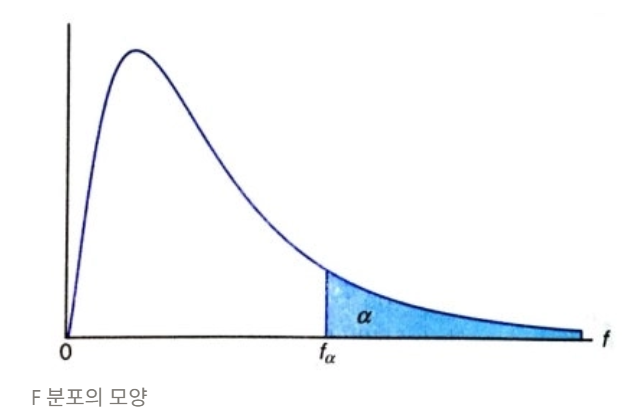  
    F-통계량의 유의확률 = F-통계량의 p-value. 즉 Prob < 0.005이면 귀무가설 기각. F-통계량과 반비례. 그림에서 오른쪽 꼬리 면적에 해당한다.
    - **T-통계량**: **각 독립변수 X가 종속변수 y에 유의미한 영향을 미치는지** 판단. H0 = 해당 독립변수의 회귀 계수가 0 (= 해당 독립변수는 y에 영향 X), H1= 해당 독립변수의 회귀 계수는 0 아님(= 해당 독립변수는 y에 유의미한 영향)
    > P>|T-statistic| 이란?  

    T-통계량의 유의확률. T-통계량은 추정한 계수가 0에서 몇 표준오차만큼 떨어져있는지를 나타낸다. 즉 *|t|가 크면 0에서 멀다는 뜻이므로 영향이 있는 것 = p-value가 작은 것*.  
    > P >∣t∣ = P(∣T∣>∣t∣). 현재 관측된 t값보다 더 극단적인 값이 나올 확률
- 통계지표 - 성능 평가
    - **결정계수**(R-squared): 회귀 모델이 데이터를 얼마나 잘 설명하는지. **값이 높을수록 좋음** 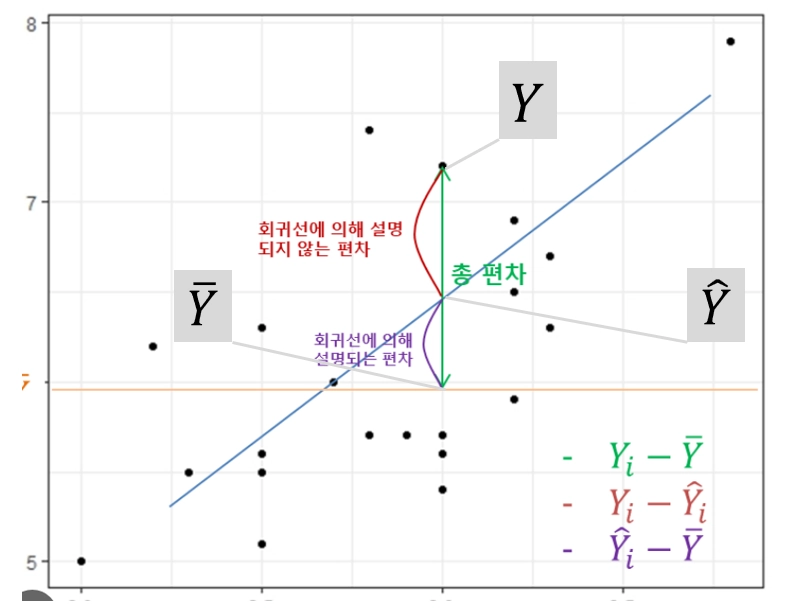  
        - **SST :** 평균($\bar{Y}$)으로 예측했을 때의 총 오차 (전체 변동성)
        - **SSE:** 모델($\hat{Y}$)이 예측하고 남은 오차(모델이 설명 불가능)
        - **SSR:** 평균에 비해 모델이 얼마나 더 잘 맞혔는지 (모델의 성과)
    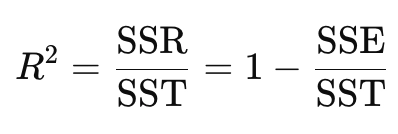  
        - 1에 가까울수록 SSE가 0에 가까워지므로 모델이 잘 설명한다는 의미
    - **조정된 결정계수**(Adjusted R-squared): $R^2$은 독립변수 개수가 늘어나면 증가한다는 한계를 지녀서 이걸 극복하기 위해 등장한 것 $$ \overline{R}^2 = \frac{SSR}{SST}\frac{n-1}{n-k}=1-(\frac{SSE/(n-k)}{SST/(n-1)}) $$
    (n = 샘플 수, k = 독립변수 개수)  
        - 변수의 개수(k)가 증가하면 전체 값은 감소 => 변수 개수에 따른 설명력 추가 부분을 상쇄하는 효과 = 패널티 부여
    - **AIC, BIC(SC)**: 정보 기준(information criteria). **값이 낮을수록 좋음**
    > AIC는 BIC에 비해 복잡성에 대한 패널티 ↓, BIC는 AIC보다 더 엄격한 기준으로 데이터의 양에 따라 더 강한 패널티 부과

# 비선형회귀
## 다항식 회귀 모델
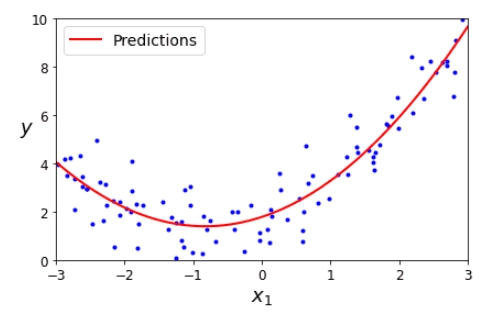  
$$ Y=a+bX+cX^2+dX^3+\cdot\cdot\cdot $$
- 독립변수에 **거듭제곱 항을 추가**해 **데이터의 곡선적 특징 설명**
- 기존 선형모델에 거듭제곱 항 포함해서 모델 확장 후 선형 회귀 적용
- 장점: 선형모델에 비해 회귀선을 데이터를 더 정확하게 설명 가능
- 단점: 독립변수 많이 사용하면 과적합 가능
> 언제 쓰나요?  

데이터 패턴이 곡선을 그릴 때, 시간에 따라 변화하는 속도가 다를 때
## 지수 회귀 모델
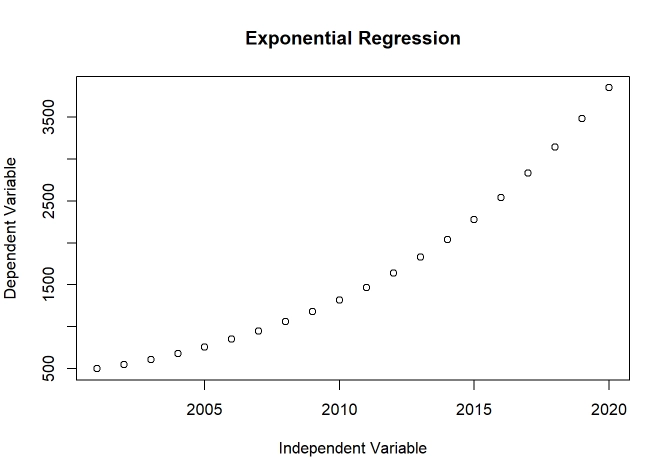  
- **종속변수 y가 지수적으로 변화할 때** 사용. 즉 데이터가 $ Y = ae^{bX} $의 수식을 따를 때.
- **종속변수 y에 로그를 취한 후 선형 회귀 적용** => 양변에 ln 취하면 선형회귀 식과 동일한 형태 ($ \ln Y=\ln a+bX $)
- 현재 모델은 로그를 취한 상태이므로 y값 예측 시 **예측값에 지수함수 적용해서 복원**
> 언제 쓰나요?  

값이 시간에 따라 지수적으로 변화할 때   ex) 기술 발전, 투자 수익률 등
## 로그 회귀 모델
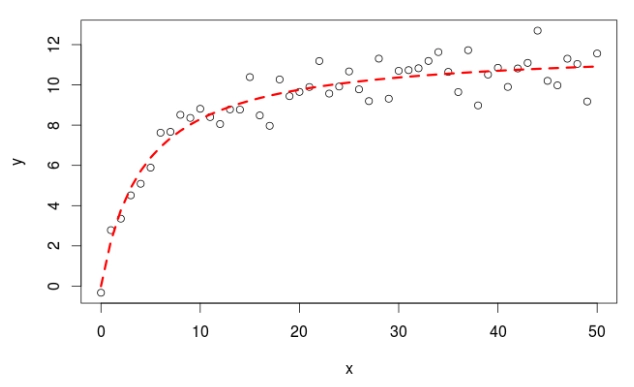  
- **종속변수와 독립변수 간의 관계가 로그함수를 통해 더 잘 표현될 때**. 즉 데이터가 $ Y=a+b\log(X) $의 수식을 따를 떄.
- **기존의 독립변수 X에 로그를 취한 후 선형회귀 적용** (선형식의 X 자리에 logX가 들어간 거니까)
- 선형식에서 양변에 무언가를 취한 게 아니기 때문에 y는 그대로 -> **예측값에 별도 처리 X**
> 언제 쓰나요?  

데이터가 초기에 빠르게 증가하고 점진적으로 감소할 때    ex) 인구성장, 감염병 확산
## 스플라인 회귀
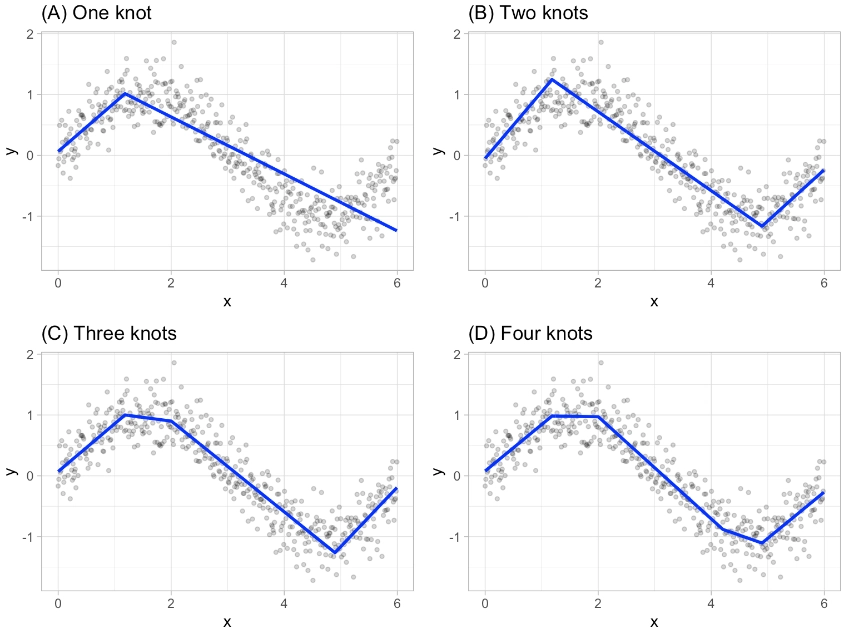  
- 데이터를 구간별로 나누고 **각 구간에서 다른 선형/비선형 함수(별도의 회귀모델)를 적용**해서 예측
- 구간 경계에서 **연속성 유지**해야함  
$$ Y = \begin{cases} a_1 + b_1X & \text{if } X < c_1 \\a_2 + b_2X & \text{if } c_1 \leq X < c_2 \\\cdots \\a_n + b_nX & \text{if } X \geq c_{n-1}\end{cases} $$
> 언제 쓰나요?  

데이터 패턴이 여러 구간에서 서로 다르게 나타날 때   ex) 소매 데이터 (계절에 따라 판매량 상이)